#Task 6: Customer Segmentation

##Problem Statement :

- The objective of this project is to group customers based on purchasing behavior.

##Dataset Details :

- I used the Mall Customer dataset containing age, gender, annual income, and spending score.

##Approach :

- I cleaned the data, applied the K-Means clustering algorithm, and visualized customer groups.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Mall_Customers.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
from sklearn.preprocessing import StandardScaler

# Headle Cetegorical data
#Machine learning works with numbers only

df['Gender'] = df['Gender'].map({'male':0,'Female':1})



##Feature Selection

- Annual Income and Spending Score were selected because these features best represent customer purchasing behavior and are useful for market segmentation.

In [ ]:
#Feature Selection

X = df[['Annual Income (k$)','Spending Score (1-100)']]


##Feature Scaling

- Feature scaling ensures that all variables contribute equally to the clustering process. Without scaling, larger values could dominate the clustering algorithm.

In [ ]:
#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Insights

- WCSS decreases as the number of clusters increases.
- The elbow point indicates the optimal number of clusters.
- Five clusters provide a good balance between simplicity and accuracy.

In [ ]:
from sklearn.cluster import KMeans as kmeans


# Find the Best number of Cluster Using ELBOW METHOD

wcss = []

for i in range(1,11):

    kmeans_model = kmeans(n_clusters=i,random_state=42)

    kmeans_model.fit(X_scaled)

    wcss.append(kmeans_model.inertia_)

##K-Means Clustering

- K-Means clustering groups customers into distinct segments based on similar spending behavior and annual income.

In [ ]:

# K-Means Clustering
kmeans_model = kmeans(
    n_clusters=5,
    random_state=42
)
y_kmeans = kmeans_model.fit_predict(X_scaled)


# Add Cluster Column
df['Cluster'] = y_kmeans

##Cluster Visualization

- The scatter plot displays customer groups identified by K-Means clustering. Each color represents a different customer segment.

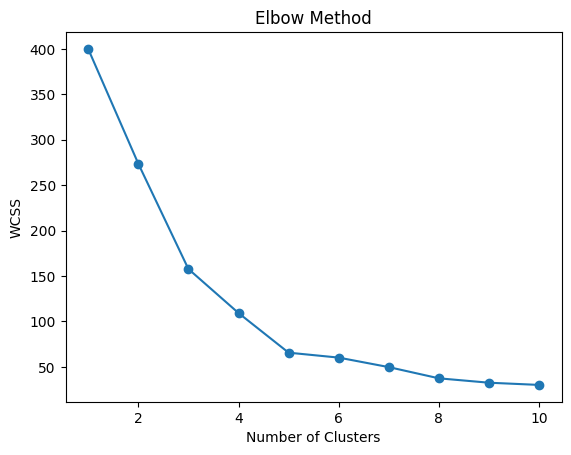

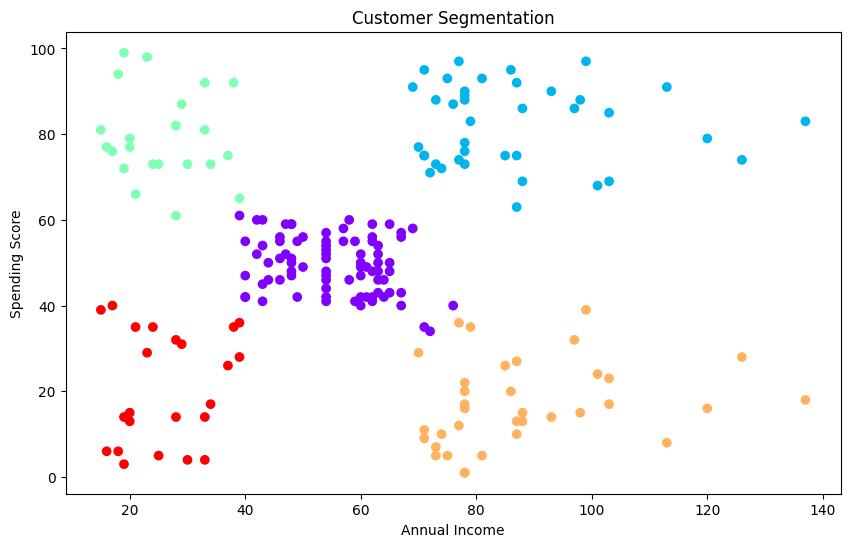

In [ ]:
import matplotlib.pyplot as plt

# Plot Elbow Graph
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Visualization
plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap='rainbow'
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation')

plt.show()

# Customer Segments and Insights

## Segment 1: High Income – High Spending
- Premium customers.
- High purchasing power.
- Important for loyalty programs.

## Segment 2: High Income – Low Spending
- Wealthy but less engaged.
- Opportunity for targeted promotions.

## Segment 3: Low Income – High Spending
- Frequent shoppers.
- Respond well to discounts and offers.

## Segment 4: Low Income – Low Spending
- Budget-conscious customers.
- May require value-based marketing.

## Segment 5: Medium Income – Medium Spending
- Average customer group.
- Stable contributors to overall sales.

# Conclusion

Customer segmentation was successfully performed using K-Means clustering.

## Key Findings:
- Five distinct customer groups were identified.
- Annual income and spending score effectively separate customer behaviors.
- Different customer segments require different marketing strategies.
- Customer segmentation can improve customer satisfaction and business growth.

The results can help businesses make better marketing and customer relationship decisions.